# A paper-inspired grid-world shield for tabular Q-learning

This notebook uses the shared model in `finite_mdp.py`.  The 5×4 layout is a
compact **adaptation**, not an exact reproduction, of the grid world released
with Alshiekh et al., *Safe Reinforcement Learning via Shielding* (AAAI 2018).

```text
44#.1
..#..
.3g2.
..#..
```

The learner proposes `north`, `east`, `south`, `west`, or `wait`.  The visible
cell is only one state factor: the full model also records whether gate `g` is
blocked and which region is expected next in the ordered tour `1→2→3→4`.

map:
44#.1
..#..
.3g2.
..#..
physical cells: 17
full product states: 17 cells × 2 gate states × 4 monitor stages = 136


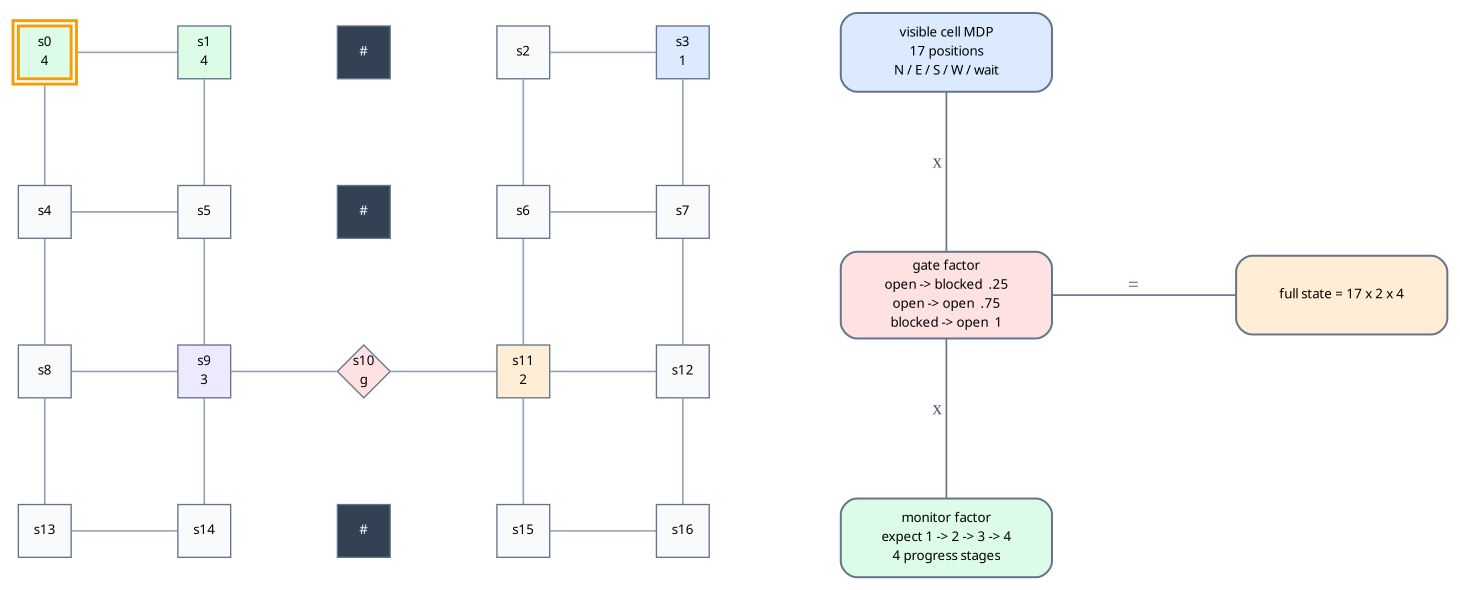

DOT characters: 4021
graph paper_gridworld {
  graph [layout=neato, bgcolor="white", margin=0.08, overlap=false, outputorder=edgesfirst];
  node [fontname="DejaVu Sans", fontsize=10, width=0.55, height=0.55, fixedsize=true, color="#64748b"];
  edge [penwidth=1.25];
  cell_0 [label="s0\n4", pos="0.00,3.45!", shape=box, style=filled, fillcolor="#dcfce7", peripheries=2, color="#f59e0b", penwidth=2.2];
  cell_1 [label="s1\n4", pos="1.15,3.45!", shape=box, style=filled, fillcolor="#dcfce7"];
  cell_2 [label="s2", pos="3.45,3.45!", shape=box, style=filled, fillcolor="#f8fafc"];
  cell_3 [label="s3\n1", pos="4.60,3.45!", shape=box, style=filled, fillcolor="#dbeafe"];
  cell_4 [label="s4", pos="0.00,2.30!", shape=box, style=filled, fillcolor="#f8fafc"];
  cell_5 [label="s5", pos="1.15,2.30!", shape=box, style=filled, fillcolor="#f8fafc"];
  cell_6 [label="s6", pos="3.45,2.30!", shape=box, style=filled, fillcolor="#f8fafc"];
  cell_7 [label="s7", pos="4.60,2.30!", shape=box, style=filled, fillc

In [1]:
from collections import defaultdict
from pathlib import Path
import random

from IPython.display import SVG, Image, display
import acacia_boomslang as ab

from finite_mdp import (
    ACTIONS,
    INPUT_APS,
    OUTPUT_APS,
    ProductState,
    assumed_ltl,
    bare_ltl,
    paper_gridworld,
    to_dot,
    write_artifacts,
)

world = paper_gridworld()
generated = Path("generated")
artifacts = write_artifacts(generated, world)

print("map:")
print("\n".join(world.rows))
print("physical cells:", len(world.physical_states))
print("full product states: 17 cells × 2 gate states × 4 monitor stages =", world.product_state_count)
display(Image(filename=str(artifacts["mdp_png"])))

# The canonical source used to make the PNG is available for inspection.
mdp_dot = to_dot("mdp", world)
print("DOT characters:", len(mdp_dot))
print("\n".join(mdp_dot.splitlines()[:12]), "\n  ...")

## 1. Synthesize the action envelope

Acacia receives the **negation** of the desired formula and builds a universal
co-Büchi automaton for bad plays.  Its only environment input is `blocked`.
The system outputs binary encodings of the candidate successor cell and monitor
stage, plus `tour_complete`.

The guarantees enforce valid wall/gate motion, legal adjacency, deterministic
monitor updates, and infinitely many completed tours.  They conflict if the
environment can keep the chokepoint closed forever; the operative assumption is
`GF !blocked`.

In [2]:
def negated(formula):
    return f"!({formula})"


def vector_values(vector):
    # Explicit indexing is robust across SWIG sequence versions.
    return tuple(vector[index] for index in range(len(vector)))


def antichain_heads(region):
    return [vector_values(head) for head in region]


def build_game(formula, k):
    game = ab.create_twa(negated(formula), list(INPUT_APS), list(OUTPUT_APS))
    ab.preprocess_aut_standard(game, k_max=k)
    ab.set_bool_thresh_no_bool_states(game, k_max=k)
    result = ab.solve_acacia_safety_game(
        game, k_max=k, k_min=k, k_inc=1
    )
    return game, result


class WinningRegionShield:
    # Map movement proposals to encodings and retain winning successors.

    def __init__(self, game, result):
        if not result.is_real():
            raise ValueError("a shield requires a realizable game")
        self.game = game
        self.result = result  # Keep the native owner alive.
        self.region = result.get_winning_region()
        self.k = self.region.k()

    def initial(self):
        return ab.get_initial_state(self.game)

    def successor(self, state_vector, state, action):
        valuation = world.valuation(state, action)
        true_aps = [name for name, value in valuation.items() if value]
        false_aps = [name for name, value in valuation.items() if not value]
        return ab.successor(
            self.game,
            state_vector,
            ab.StringVector(true_aps),
            ab.StringVector(false_aps),
            self.k,
        )

    def allowed(self, state_vector, state):
        return [
            action
            for action in ACTIONS
            if self.region.contains(self.successor(state_vector, state, action))
        ]

    def choose(self, state_vector, state, proposal, mode="permissive"):
        allowed = self.allowed(state_vector, state)
        if not allowed:
            raise RuntimeError("no action remains inside the winning region")
        if mode == "fixed":
            action = allowed[0]
        elif mode == "permissive":
            action = proposal if proposal in allowed else allowed[0]
        else:
            raise ValueError(mode)
        successor = self.successor(state_vector, state, action)
        return action, successor, action != proposal

In [3]:
bare_game, bare_result = build_game(bare_ltl(world), k=16)
game_k16, result_k16 = build_game(assumed_ltl(world), k=16)
game_k20, result_k20 = build_game(assumed_ltl(world), k=20)
shield_k16 = WinningRegionShield(game_k16, result_k16)
shield_k20 = WinningRegionShield(game_k20, result_k20)

print("bare guarantees realizable:", bare_result.is_real())
print("with GF !blocked, realizable at k=16:", result_k16.is_real())
print("preprocessed UCB states:", ab.num_states(game_k16))
print("k=16 antichain maxima:", len(shield_k16.region))
print("k=20 antichain maxima:", len(shield_k20.region))

assert not bare_result.is_real()
assert result_k16.is_real()
assert result_k20.is_real()

initial_product = world.initial_state(blocked=False)
initial_vector = shield_k16.initial()
initial_allowed = shield_k16.allowed(initial_vector, initial_product)
print("initial ordinary actions:", list(ACTIONS))
print("initial shield actions:", initial_allowed)
assert "north" not in initial_allowed and "west" not in initial_allowed
assert all(not world.action_outcome(initial_product, action).collision for action in initial_allowed)

# Follow a legal open-gate history to the cell immediately left of g.
gate_product, gate_vector = initial_product, initial_vector
for action in ("east", "south", "south"):
    gate_vector = shield_k16.successor(gate_vector, gate_product, action)
    next_cell, collision = world.move(gate_product.cell, action, False)
    next_progress, _ = world.advance_progress(gate_product.progress, next_cell)
    assert not collision
    gate_product = ProductState(next_cell, False, next_progress)
gate_product = ProductState(gate_product.cell, True, gate_product.progress)
blocked_gate_allowed = shield_k16.allowed(gate_vector, gate_product)
print("left of a blocked gate, shield actions:", blocked_gate_allowed)
assert "east" not in blocked_gate_allowed

bare guarantees realizable: False
with GF !blocked, realizable at k=16: True
preprocessed UCB states: 27
k=16 antichain maxima: 146
k=20 antichain maxima: 146
initial ordinary actions: ['north', 'east', 'south', 'west', 'wait']
initial shield actions: ['east', 'south', 'wait']
left of a blocked gate, shield actions: ['north', 'south', 'west', 'wait']


### The object the shield is a membership test against

`ab.get_aut_hoa` hands back the preprocessed universal co-Buchi automaton, and Spot
draws it.  The **double circles are the two bad states**: the monitor carries one
counter per state, counting how long each bad state has been live, and the shield's
whole job is to keep that vector of counters inside the winning region above.

Edge labels are dropped before drawing.  Each is a cube over all nine atomic
propositions, and Graphviz widens the picture to fit them: with labels this
automaton lays out about eleven metres wide and is unreadable at any zoom.  Without
them it is a band roughly three times wider than tall -- which is also the layout
the talk's animation uses, so this is literally the same picture.

27 UCB states, 60 edges, 146 antichain maxima in the winning region


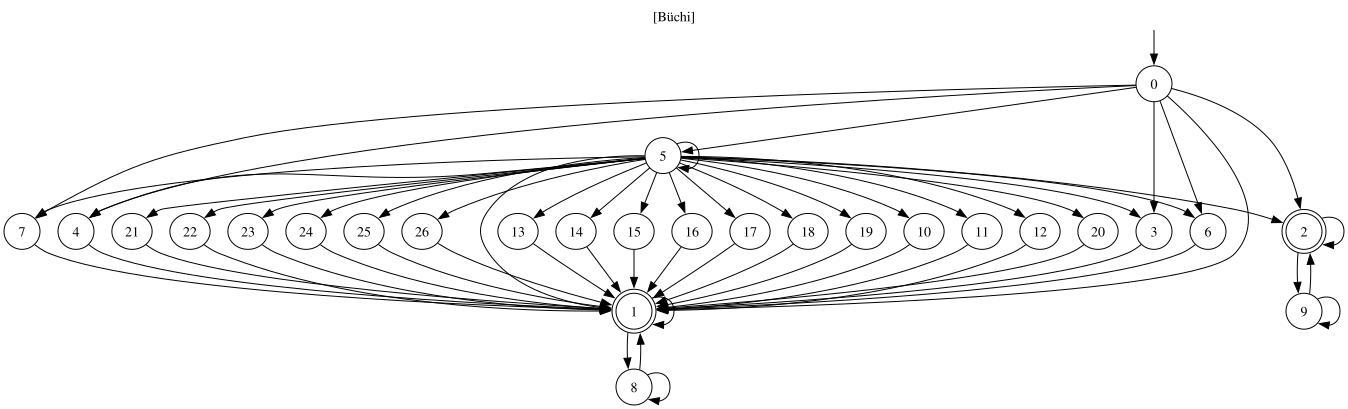

In [4]:
import re
import subprocess

try:
    import spot
except ImportError:
    print("spot is not importable here, so skipping the automaton view.")
    print("The image ghcr.io/gaperez64/acacia-boomslang ships Spot with its bindings;")
    print("locally, start Jupyter with")
    print("  PYTHONPATH=/usr/local/lib64/python3.13/site-packages")
else:
    ucb = spot.automaton(ab.get_aut_hoa(game_k16))
    print(f"{ucb.num_states()} UCB states, {ucb.num_edges()} edges, "
          f"{len(shield_k16.region)} antichain maxima in the winning region")

    # ".v" is the vertical layout; strip the edge labels only, since removing
    # the graph label and the state names as well leaves Graphviz nothing to
    # draw.  Same treatment the talk's animation gives it.
    drawing = ucb.to_str("dot", ".v")
    drawing = "\n".join(
        re.sub(r' \[label="[^"]*"\]', "", line) if "->" in line else line
        for line in drawing.splitlines()
    )
    svg = subprocess.run(["dot", "-Tsvg"], input=drawing,
                         capture_output=True, text=True, check=True).stdout
    display(SVG(svg))

## 2. Fixed controller versus permissive shield

A fixed mode takes one deterministic winning action.  The permissive mode keeps
the learner's proposal whenever its encoded successor remains in the winning
region.  Both are safe, but the latter is less intrusive.

In [5]:
def compare_mode(mode, seed=11, steps=240):
    rng = random.Random(seed)
    state = world.initial_state(blocked=False)
    vector = shield_k16.initial()
    interventions = collisions = tours = 0
    for _ in range(steps):
        proposal = rng.choice(ACTIONS)
        action, next_vector, changed = shield_k16.choose(
            vector, state, proposal, mode=mode
        )
        transition = world.sample_successor(state, action, rng)
        interventions += int(changed)
        collisions += int(transition.collision)
        tours += int(transition.completed)
        state, vector = transition.state, next_vector
    return interventions, collisions, tours


fixed_summary = compare_mode("fixed")
permissive_summary = compare_mode("permissive")
print("                         interventions  collisions  tours")
print("fixed controller:       ", fixed_summary)
print("permissive win. region: ", permissive_summary)
assert fixed_summary[1] == permissive_summary[1] == 0
assert permissive_summary[0] < fixed_summary[0]

                         interventions  collisions  tours
fixed controller:        (185, 0, 13)
permissive win. region:  (145, 0, 12)


## 3. Seeded tabular Q-learning behind the shield

The reward is exactly `+1` when a tour completes, `−1` on collision, and
`−0.01` per step.  The unshielded and shielded runs use the same seeds and
ordinary five-action Q-table.  The shield filters the proposal; it does not
replace movement actions with Boolean control signals.

In [6]:
def train(seed, use_shield, episodes=240, horizon=64):
    policy_rng = random.Random(seed)
    q = defaultdict(lambda: [0.0] * len(ACTIONS))
    rewards, collisions, tours, interventions = [], [], [], []

    for episode in range(episodes):
        environment_rng = random.Random(seed * 100_000 + episode)
        state = world.initial_state(blocked=False)
        vector = shield_k16.initial() if use_shield else None
        totals = {"reward": 0.0, "collisions": 0, "tours": 0, "interventions": 0}
        epsilon = max(0.04, 0.35 * (1.0 - episode / episodes))

        for _ in range(horizon):
            key = (state.cell, state.blocked, state.progress)
            if policy_rng.random() < epsilon:
                proposal_index = policy_rng.randrange(len(ACTIONS))
            else:
                proposal_index = max(range(len(ACTIONS)), key=q[key].__getitem__)
            proposal = ACTIONS[proposal_index]

            if use_shield:
                allowed = shield_k16.allowed(vector, state)
                if proposal in allowed:
                    action = proposal
                else:
                    action = max(allowed, key=lambda item: q[key][ACTIONS.index(item)])
                next_vector = shield_k16.successor(vector, state, action)
            else:
                action, next_vector = proposal, None

            transition = world.sample_successor(state, action, environment_rng)
            reward = transition.reward
            next_state = transition.state
            next_key = (next_state.cell, next_state.blocked, next_state.progress)
            old = q[key][proposal_index]
            target = reward + 0.94 * max(q[next_key])
            q[key][proposal_index] = old + 0.24 * (target - old)

            totals["reward"] += reward
            totals["collisions"] += int(transition.collision)
            totals["tours"] += int(transition.completed)
            totals["interventions"] += int(action != proposal)
            state, vector = next_state, next_vector

        rewards.append(totals["reward"])
        collisions.append(totals["collisions"])
        tours.append(totals["tours"])
        interventions.append(totals["interventions"])

    return {
        "reward": rewards,
        "collisions": collisions,
        "tours": tours,
        "interventions": interventions,
        "q": q,
    }


unshielded = train(seed=23, use_shield=False)
shielded = train(seed=23, use_shield=True)

def final_mean(values, count=40):
    return sum(values[-count:]) / count

print("unshielded collisions:", sum(unshielded["collisions"]))
print("shielded collisions:", sum(shielded["collisions"]))
print("shield interventions:", sum(shielded["interventions"]))
print("completed tours (unshielded / shielded):",
      sum(unshielded["tours"]), "/", sum(shielded["tours"]))
print("mean return, final 40 episodes (unshielded / shielded):",
      round(final_mean(unshielded["reward"]), 3), "/",
      round(final_mean(shielded["reward"]), 3))

assert sum(unshielded["collisions"]) > 0
assert sum(shielded["collisions"]) == 0

unshielded collisions: 750
shielded collisions: 0
shield interventions: 6295
completed tours (unshielded / shielded): 628 / 732
mean return, final 40 episodes (unshielded / shielded): 2.56 / 2.56


## 4. The co-Büchi bound changes the waiting envelope

Both bounds enforce the same specification.  A larger bound retains more
history-dependent slack: at the start, `k=16` certifies one wait while `k=20`
certifies five.  The comparison below is computed from the two winning regions,
not staged labels.

k=16 allowed after 0 waits: ['east', 'south', 'wait']
k=16 allowed after 1 wait:  ['east', 'south']
k=20 allowed after 1 wait:  ['east', 'south', 'wait']
maximum certified consecutive waits, k=16 / k=20: 1 / 5


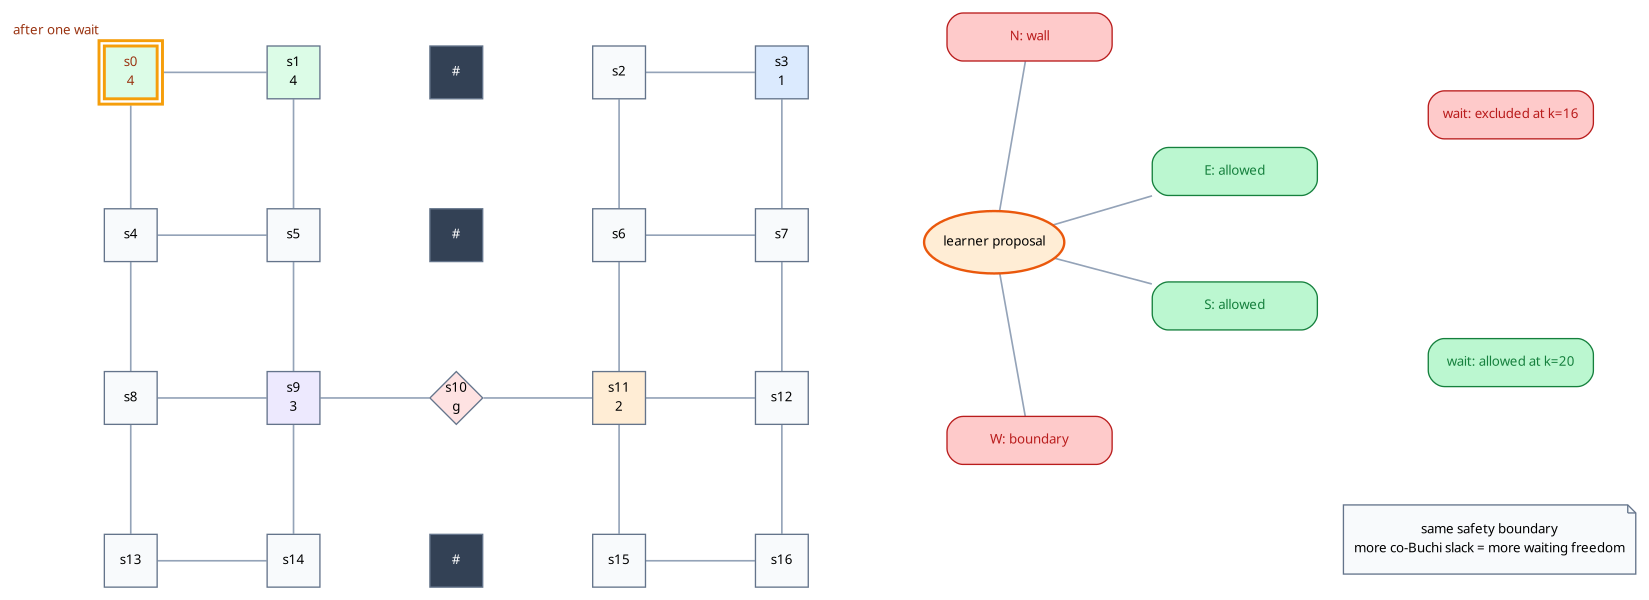

In [7]:
def consecutive_wait_envelope(shield):
    state = world.initial_state(blocked=False)
    vector = shield.initial()
    allowed_by_step = []
    while True:
        allowed = shield.allowed(vector, state)
        allowed_by_step.append(allowed)
        if "wait" not in allowed:
            return allowed_by_step
        vector = shield.successor(vector, state, "wait")


waits_k16 = consecutive_wait_envelope(shield_k16)
waits_k20 = consecutive_wait_envelope(shield_k20)
print("k=16 allowed after 0 waits:", waits_k16[0])
print("k=16 allowed after 1 wait: ", waits_k16[1])
print("k=20 allowed after 1 wait: ", waits_k20[1])
print("maximum certified consecutive waits, k=16 / k=20:",
      len(waits_k16) - 1, "/", len(waits_k20) - 1)
assert len(waits_k16) - 1 == 1
assert len(waits_k20) - 1 == 5
assert len(waits_k20[1]) > len(waits_k16[1])

display(Image(filename=str(artifacts["shield_png"])))

### Takeaway

The synthesized object is an action envelope over the full product state.
The temporal specification establishes the boundary; tabular Q-learning ranks
ordinary movement actions inside it, with zero observed shielded collisions.